## Post-project IRB Likert-scale questions
df1: participant background & level, engagement & authenticity, learning process & self-efficacy, tool/feedback usefulness, cognitive load, team/coordination, group/individual preferences.
- Data Collection: Final Project Chat App (116 participants /130 students)
- Goal: Project learning, encouragement, and tool effectiveness
- Analysis Method: Percentage of each likert option

In [1]:
import os
os.environ["PATH"] += ":/Library/TeX/texbin"
os.environ["PATH"] += ":/usr/local/texlive/2026basic/bin/universal-darwin/latex"
os.environ["PATH"] += ":/usr/local/texlive/2026basic/bin/universal-darwin"

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import textwrap

import re


df = pd.read_csv("IRB_EoT_survey_project.csv", header=1)
pd.set_option('display.max_colwidth', None)

In [2]:
import shutil
print(shutil.which("latex"))
print(os.environ["PATH"])

/usr/local/texlive/2026basic/bin/universal-darwin/latex
/Users/belencsf/.pyenv/versions/3.10.12/bin:/usr/local/texlive/2026basic/bin/universal-darwin:/usr/local/texlive/2026basic/bin/universal-darwin/latex:/Library/TeX/texbin:/opt/homebrew/opt/openjdk@17/bin:/Users/belencsf/.gem/ruby/4.0.0/bin:/opt/homebrew/opt/ruby/bin:/Users/belencsf/.gem/ruby/4.0.0/bin:/opt/homebrew/opt/ruby/bin:/Users/belencsf/Library/Python/3.9/bin:/usr/bin:/bin:/usr/sbin:/sbin:/usr/local/bin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/pkg/env/global/bin:/Library/TeX/texbin:/opt/homebrew/bin:/Library/TeX/texbin:/usr/local/texlive/2026basic/bin/universal-darwin/latex:/usr/local/texlive/2026basic/bin/universal-darwin


In [3]:
# What has changed from last version:
  # remove learning process data and keep tool usefulness
  # Separate by Category
  # Put (n=116) in title
  # Change scale of neutrals portion to match overall sentiment

In [18]:
df.columns

Index(['Timestamp',
       'How many coding-focused classes had you taken before college?',
       'How many coding-focused classes had you taken IN COLLEGE before INFO 330?',
       'Engagement & authenticity [This project felt like a real‑world scenario.]',
       'Engagement & authenticity [I was motivated to make the app work.]',
       'Engagement & authenticity [The chat app context made database work feel relevant.]',
       'Learning process & self‑efficacy [The project was challenging in a productive way.]',
       'Learning process & self‑efficacy [The project let me make decisions rather than just follow steps.]',
       'Learning process & self‑efficacy [I can explain how constraints improve data quality.]',
       'Learning process & self‑efficacy [I can design tables and keys for a new app feature.]',
       'Learning process & self‑efficacy [I can debug SQL by comparing expected vs. actual outputs.]',
       'Learning process & self‑efficacy [I could apply what I learned

In [20]:
df = df.rename(columns={
    'Learning process & self‑efficacy [The project activities matched what I was expected to learn in the course.]': 'Learning process & self‑efficacy [The project matched what I was expected to learn in the course.]',
    "Cognitive load / friction [The technical setup (VPN/pgAdmin/login) was easy to navigate.]": "Cognitive load / friction [The technical setup (VPN and pgAdmin) was easy to navigate.]",
"Learning process & self‑efficacy [I could apply what I learned in this project to a different app or database scenario.]": "Learning process & self‑efficacy [I could apply what I learned in this project to a different db scenario.]"})

In [21]:
# ## ADD one, wiht *.

# Group			80.17%
# Individual		16.38%
# Mixed / Depends	3.45%

# 1. Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
matplotlib.rc('text', usetex=True)

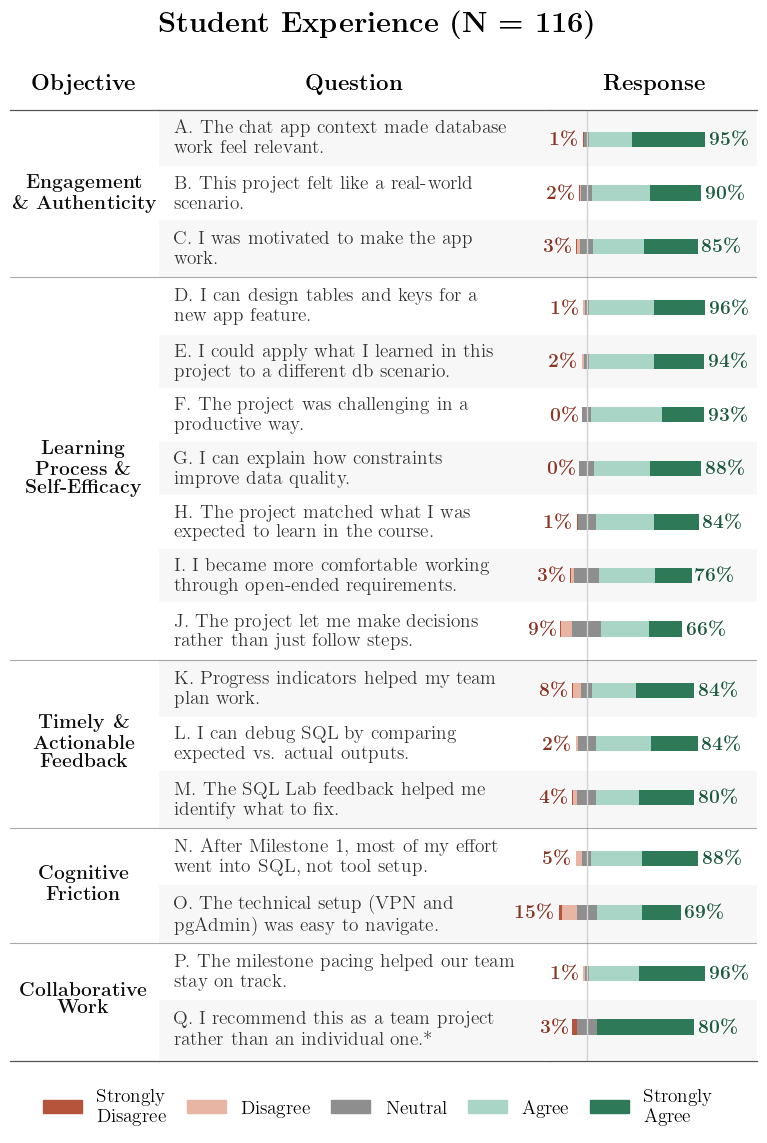

In [22]:

# plt.rcParams["font.family"] = "Arial"
font_size = 14
plt.rcParams["font.size"]   = font_size


LIKERT_ORDER = [
    "Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"
]

COLORS = {
    "Strongly Disagree": "#b5543a",
    "Disagree":          "#e8b5a4",
    "Neutral":           "#8e8e8e",
    "Agree":             "#a8d5c5",
    "Strongly Agree":    "#2e7a58"
}

FILTERED_QUESTION = (
    "Learning process & self‑efficacy [I can debug SQL by comparing expected vs. actual outputs.]"
)

def escape_latex(s):
    return s.replace('&', r'\&') \
            .replace('$', r'\$') \
            .replace('#', r'\#').replace('_', r'\_') \
            .replace('{', r'\{') \
            .replace('}', r'\}').replace('~', r'\textasciitilde{}') \
            .replace('^', r'\^{}')

def tex_bold(s):
    parts = s.split('\n')
    bolded = [r"\textbf{" + p + "}" for p in parts]
    return r"\shortstack{" + r"\\".join(bolded) + "}"


CATEGORY_LABELS = {
    "Engagement & Authenticity":        escape_latex("Engagement\n& Authenticity"),
    "Learning Process & Self‑Efficacy": escape_latex("Learning\nProcess & \nSelf-Efficacy"),
    "Tool/Feedback Usefulness":         escape_latex("Timely &\nActionable\nFeedback"),
    "Cognitive Load / Friction":        escape_latex("Cognitive \nFriction"),
    "Team/Coordination":                escape_latex("Collaborative \nWork"),
}

BORDER_COLOR = "#555555"

def split_question(text):
    if "[" in text and "]" in text:
        category = text.split("[")[0].strip()
        question  = text.split("[")[-1].replace("]", "").strip()
    else:
        category, question = "Other", text
    return category, question

def wrap_text(text, width=36):
    tmp = "\n".join(textwrap.wrap(text, width))
    if "pgAdmin" in tmp:
        a, b = tmp.split("pgAdmin")
        b = b.replace('\n', ' ')
        return a + "pgAdmin" + b
    return tmp



questions = [c for c in df.columns if "[" in c and c != FILTERED_QUESTION]
df_likert  = df[questions]

summary_rows = []
for col in df_likert.columns:
    category, question = split_question(col)
    counts = (
        df_likert[col].value_counts(normalize=True)
        .reindex(LIKERT_ORDER).fillna(0) * 100
    )
    summary_rows.append({
        "category":          category.title(),
        "question":          escape_latex(wrap_text(question)),
        "Strongly Disagree": counts["Strongly Disagree"],
        "Disagree":          counts["Disagree"],
        "Neutral":           counts["Neutral"],
        "Agree":             counts["Agree"],
        "Strongly Agree":    counts["Strongly Agree"]
    })
summary_rows.append(
    {
        "category":          'Team/Coordination',
        "question":          escape_latex(wrap_text('I recommend this as a team project rather than an individual one.*')),
        "Strongly Disagree": 3.45,
        "Disagree":          0,
        "Neutral":           16.38,
        "Agree":             0,
        "Strongly Agree":    80.17
    })

summary_df = pd.DataFrame(summary_rows)
summary_df["total_pos"] = summary_df["Agree"] + summary_df["Strongly Agree"]
summary_df["total_neg"] = summary_df["Strongly Disagree"] + summary_df["Disagree"]

category_avg_pos = summary_df.groupby("category")["total_pos"].mean()
summary_df["category_avg_pos"] = summary_df["category"].map(category_avg_pos)

summary_df = summary_df.sort_values(
    ["category_avg_pos", "total_pos"], ascending=[False, False]
)



BASE_H     = 3.00
LINE_EXTRA = 0.5
GAP        = 0.5

y_positions     = []
plot_rows       = []
category_ranges = []
row_heights     = []
current_y       = 0.0

# for category in summary_df["category"].unique():
for category in [
        'Engagement & Authenticity',
       'Learning Process & Self‑Efficacy',
       'Tool/Feedback Usefulness',
       'Cognitive Load / Friction',
       'Team/Coordination']:
    cat_df  = summary_df[summary_df["category"] == category]
    first_y = None

    for _, row in cat_df.iterrows():
        q_text     = row["question"]
        num_lines  = q_text.count("\n") + 1
        row_height = BASE_H + (num_lines - 1) * LINE_EXTRA

        if first_y is None:
            first_y = current_y

        bar_y = current_y + row_height / 2
        y_positions.append(bar_y)
        plot_rows.append(row)
        row_heights.append(row_height)
        current_y += row_height

    end_y = current_y
    category_ranges.append({
        "category": category,
        "mid":      first_y + (end_y - first_y) / 2,
        "divider":  current_y + GAP / 2
    })
    current_y += GAP

plot_df    = pd.DataFrame(plot_rows)
total_neg  = plot_df["total_neg"]
total_pos  = plot_df["total_pos"]
y_bars     = y_positions
BAR_HEIGHT = 1

fig, (ax_cat, ax_q, ax_main) = plt.subplots(
    ncols=3, sharey=True,
    figsize=(8, 11),
    gridspec_kw={
        "width_ratios": [1.9, 5, 2.65],
        "wspace": 0.0
    }
)

ax_cat.set_xlim(0, 1)
ax_cat.set_xticks([])
ax_cat.set_yticks([])

for cat in category_ranges:
    label = CATEGORY_LABELS.get(cat["category"], cat["category"])
    ax_cat.text(
        0.5, cat["mid"], tex_bold(label),
        ha="center", va="center",
        fontsize=font_size, fontweight="bold",
        color="#111111", multialignment="center"
    )

ax_cat.set_title(r"\textbf{" +"Objective}", fontsize=font_size*1.15, pad=font_size, fontweight="bold")
ax_q.set_title(r"\textbf{" +"Question}", fontsize=font_size*1.15, pad=font_size, fontweight="bold")
ax_main.set_title(r"\textbf{" +"Response}", fontsize=font_size*1.15, pad=font_size, fontweight="bold")

ax_q.set_xlim(0, 1)
ax_q.set_xticks([])
ax_q.set_yticks([])

n = len(y_bars)
for i, (y, rh) in enumerate(zip(y_bars, row_heights)):
    color = "#f7f7f7" if i % 2 == 0 else "white"
    y_lo = y - rh / 2
    y_hi = y + rh / 2
    # first row of a category: extend up to the divider above
    if i == 0 or y_bars[i] - rh / 2 > y_bars[i-1] + row_heights[i-1] / 2 + 0.001:
        y_lo -= GAP / 2
    # last row of a category: extend down to the divider below
    if i == n - 1 or y_bars[i+1] - row_heights[i+1] / 2 > y_bars[i] + rh / 2 + 0.001:
        y_hi += GAP / 2
    ax_q.axhspan(y_lo, y_hi, color=color, zorder=0)
    ax_main.axhspan(y_lo, y_hi, color=color, zorder=0)

for i, (_, row) in enumerate(plot_df.iterrows()):
    y = y_positions[i]
    rh = row_heights[i]
    is_first = i == 0 or y_bars[i] - rh / 2 > y_bars[i-1] + row_heights[i-1] / 2 + 0.001
    is_last  = i == n - 1 or y_bars[i+1] - row_heights[i+1] / 2 > y_bars[i] + rh / 2 + 0.001
    if is_first and not is_last:
        y_text = y - GAP / 4
    elif is_last and not is_first:
        y_text = y + GAP / 4
    else:
        y_text = y
    ax_q.text(
        0.04, y_text, f"{chr(65 + i)}. {row['question']}",
        ha="left", va="center",
        fontsize=font_size, color="#333333"
    )

neutral_half = (plot_df["Neutral"] / 2).values

# Negatives start at -(total_neg + neutral_half)
left_neg = -(plot_df["total_neg"].values + neutral_half)
for col in ["Strongly Disagree", "Disagree"]:
    vals = plot_df[col].values
    ax_main.barh(y_bars, vals, left=left_neg, color=COLORS[col], height=BAR_HEIGHT)
    left_neg += vals

# Neutral centered at 0
ax_main.barh(y_bars, plot_df["Neutral"].values, left=-neutral_half,
             color=COLORS["Neutral"], height=BAR_HEIGHT)

# Positives start at +neutral_half
left_pos = neutral_half.copy()
for col in ["Agree", "Strongly Agree"]:
    vals = plot_df[col].values
    ax_main.barh(y_bars, vals, left=left_pos, color=COLORS[col], height=BAR_HEIGHT)
    left_pos += vals

for i, y in enumerate(y_bars):
    ax_main.text(-(total_neg.iloc[i] + neutral_half[i]) - 3, y, r"\textbf{" + f"{total_neg.iloc[i]:.0f}" + r"\%}",
                 ha="right", va="center", fontsize=font_size, fontweight="bold", color="#8b3525", zorder=5)
    ax_main.text( total_pos.iloc[i] + neutral_half[i] + 3, y, r"\textbf{" + f"{total_pos.iloc[i]:.0f}" + r"\%}",
                 ha="left",  va="center", fontsize=font_size, fontweight="bold", color="#1e5c42", zorder=5)


ax_main.axvline(0, color="lightgray", lw=1)
ax_main.set_yticks([])
ax_main.set_xticks([])


ax_main.set_xlim(-30, 140)
ax_main.spines["top"].set_bounds(-30, 140)
ax_main.spines["bottom"].set_bounds(-30, 140)

for cat in category_ranges[:-1]:
    for ax in [ax_cat, ax_q, ax_main]:
        ax.axhline(cat["divider"], color=BORDER_COLOR, lw=0.8, alpha=0.5)

for ax in [ax_cat, ax_q, ax_main]:
    for side, spine in ax.spines.items():
        if side in ("left", "right"):
            spine.set_visible(False)
        else:
            spine.set_visible(True)
            spine.set_linewidth(0.9)
            spine.set_color(BORDER_COLOR)

ax_cat.invert_yaxis()
margin = 0.2
ax_cat.set_ylim(current_y - GAP / 2 + margin, -margin)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[lbl], label=wrap_text(lbl, 10))
    for lbl in LIKERT_ORDER
]
fig.legend(
    handles=legend_handles,
    loc="upper center", bbox_to_anchor=(0.5, 0.02),
    ncol=len(LIKERT_ORDER),
    fontsize=font_size, frameon=False,
    columnspacing=1
)

plt.suptitle(
    r"\textbf{" +"Student Experience (N = 116)}",
    fontsize=font_size*1.5, fontweight="semibold", y=0.985
)
# ax_main.text(0, ax_main.get_ylim()[0], "0\%", ha="center", va="bottom", fontsize=font_size, color="gray")

fig.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.show()
